#  Housing Data Analysis 

***import libraries***

In [58]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import mean_absolute_error, r2_score,accuracy_score
import seaborn as sns
sns.set_style(style="darkgrid")

In [59]:
data=pd.read_csv("housing.csv")
df=pd.DataFrame(data)

In [60]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [61]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [62]:
df['total_bedrooms']=df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [63]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [64]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [65]:
# from sklearn.preprocessing import LabelEncoder

# encoder=LabelEncoder()
# df1=encoder.fit_transform(df['ocean_proximity'])
# df.head()

In [66]:
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


In [67]:
# 1. Average rooms per household
df['rooms_per_household'] = df['total_rooms'] / df['households']

# 2. Bedrooms per room (indicates house size/luxury vs crampedness)
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']

# 3. Population per household (family/occupancy size)
df['population_per_household'] = df['population'] / df['households']

In [68]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0,6.281853,0.172096,2.181467


In [69]:
df=df.drop(['total_rooms','total_bedrooms','population','households'],axis=1)

In [70]:
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,8.3252,452600.0,0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,8.3014,358500.0,0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,7.2574,352100.0,0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,5.6431,341300.0,0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,3.8462,342200.0,0,0,0,1,0,6.281853,0.172096,2.181467


In [71]:
from sklearn.preprocessing import StandardScaler

In [72]:
scale=StandardScaler()

In [73]:
df_scale=scale.fit_transform(df)

In [74]:
df2=pd.DataFrame(df_scale,index=df.index,columns=df.columns)

In [75]:
df2.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-1.327835,1.052548,0.982143,2.344766,2.129631,-0.891156,-0.681889,-0.015566,2.830742,-0.384466,0.628559,-1.029988,-0.049597
1,-1.322844,1.043185,-0.607019,2.332238,1.314156,-0.891156,-0.681889,-0.015566,2.830742,-0.384466,0.327041,-0.888897,-0.092512
2,-1.332827,1.038503,1.856182,1.782699,1.258693,-0.891156,-0.681889,-0.015566,2.830742,-0.384466,1.155620,-1.291686,-0.025843
3,-1.337818,1.038503,1.856182,0.932968,1.165100,-0.891156,-0.681889,-0.015566,2.830742,-0.384466,0.156966,-0.449613,-0.050329
4,-1.337818,1.038503,1.856182,-0.012881,1.172900,-0.891156,-0.681889,-0.015566,2.830742,-0.384466,0.344711,-0.639087,-0.085616


<Axes: >

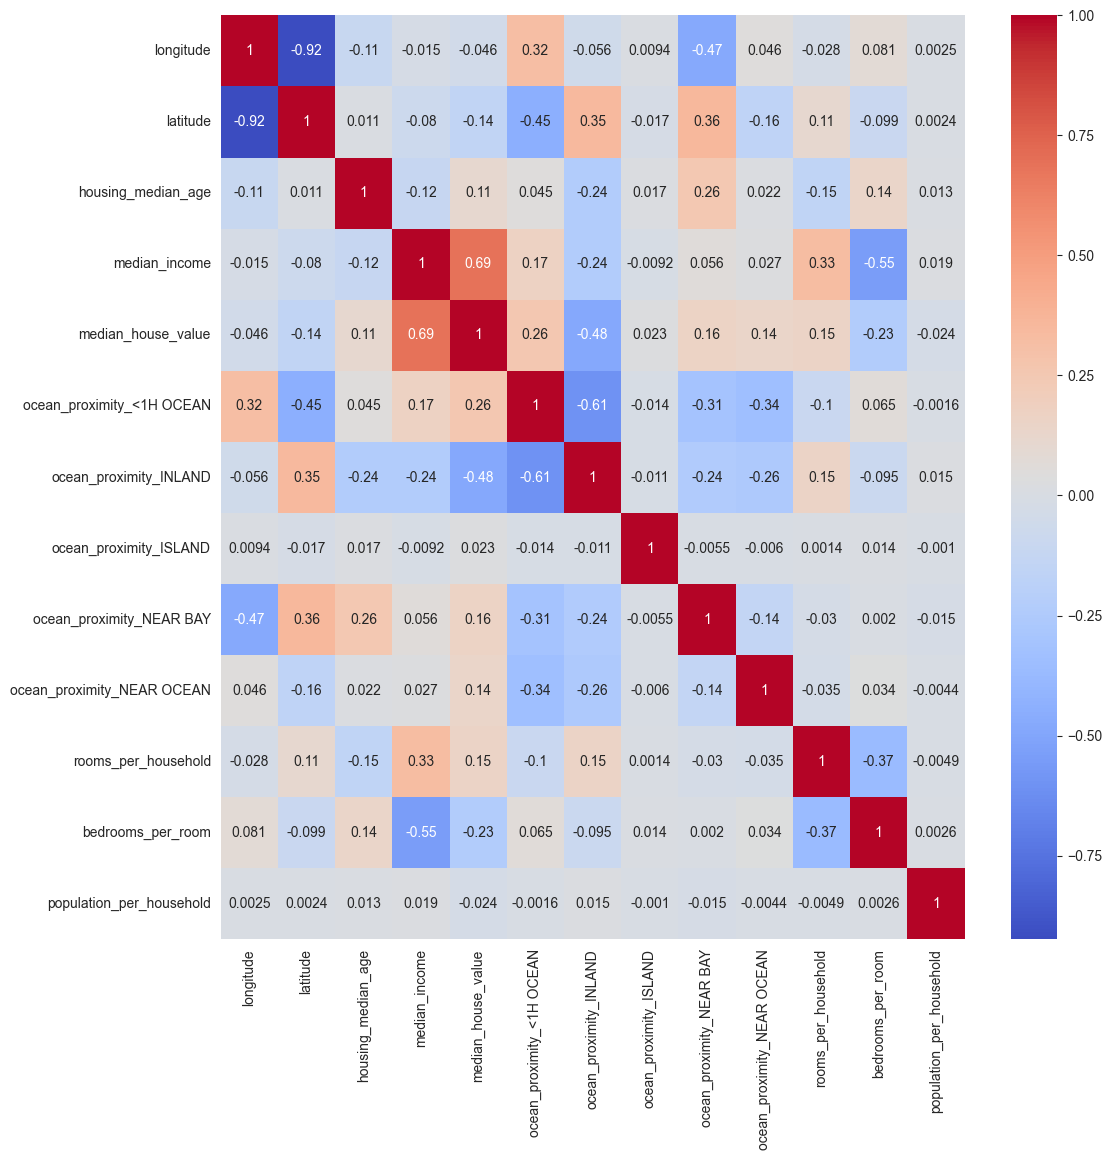

In [76]:
matrix=df2.corr()

fig=plt.figure(figsize=(12,12))

sns.heatmap(matrix,annot=True,cmap='coolwarm')

In [77]:
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,8.3252,452600.0,0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,8.3014,358500.0,0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,7.2574,352100.0,0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,5.6431,341300.0,0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,3.8462,342200.0,0,0,0,1,0,6.281853,0.172096,2.181467


In [78]:
x=df2.drop('median_house_value',axis=1)
y=df2['median_house_value']

from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

# Using Linear Regresssion

In [79]:
from sklearn.linear_model import LinearRegression
LR_model=LinearRegression()

In [80]:
LR_model.fit(xtrain,ytrain)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
y_pred=LR_model.predict(xtest)

In [82]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Calculate regression metrics
mse = mean_squared_error(ytest, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 0.4604503532478507
Root Mean Squared Error (RMSE): 0.663218028523662
R² Score: 0.5530454493034724


# Using Random Forest Regressor

In [83]:
df.head()

,longitude,latitude,housing_median_age,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,8.3252,452600.0,0,0,0,1,0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,8.3014,358500.0,0,0,0,1,0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,7.2574,352100.0,0,0,0,1,0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,5.6431,341300.0,0,0,0,1,0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,3.8462,342200.0,0,0,0,1,0,6.281853,0.172096,2.181467


In [94]:
new=df
df = df[df['median_house_value'] < 500001]
df.info()

<class 'pandas.DataFrame'>
Index: 19675 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   19675 non-null  float64
 1   latitude                    19675 non-null  float64
 2   housing_median_age          19675 non-null  float64
 3   median_income               19675 non-null  float64
 4   median_house_value          19675 non-null  float64
 5   ocean_proximity_<1H OCEAN   19675 non-null  int64  
 6   ocean_proximity_INLAND      19675 non-null  int64  
 7   ocean_proximity_ISLAND      19675 non-null  int64  
 8   ocean_proximity_NEAR BAY    19675 non-null  int64  
 9   ocean_proximity_NEAR OCEAN  19675 non-null  int64  
 10  rooms_per_household         19675 non-null  float64
 11  bedrooms_per_room           19675 non-null  float64
 12  population_per_household    19675 non-null  float64
dtypes: float64(8), int64(5)
memory usage: 2.1 MB


In [95]:
x=df.drop('median_house_value',axis=1)
y=df['median_house_value']

In [96]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [97]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    max_features='sqrt',
    random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsampl

In [98]:
y_pred=model.predict(x_test)

In [99]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R² Score: {r2}")

Mean Absolute Error (MAE): 30622.528173835173
Root Mean Squared Error (RMSE): 45244.978290097984
R² Score: 0.7946935139242611


In [100]:
df['median_house_value'].describe()

count     19675.000000
mean     192477.921017
std       97711.509613
min       14999.000000
25%      116600.000000
50%      173800.000000
75%      248200.000000
max      500000.000000
Name: median_house_value, dtype: float64

***As we can see above our data set has house values from 15k to 500k our error should not be a big problem***

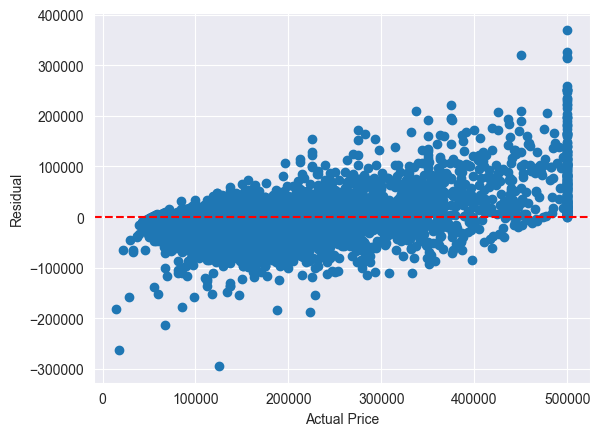

In [91]:
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Actual Price")
plt.ylabel("Residual")
plt.show()

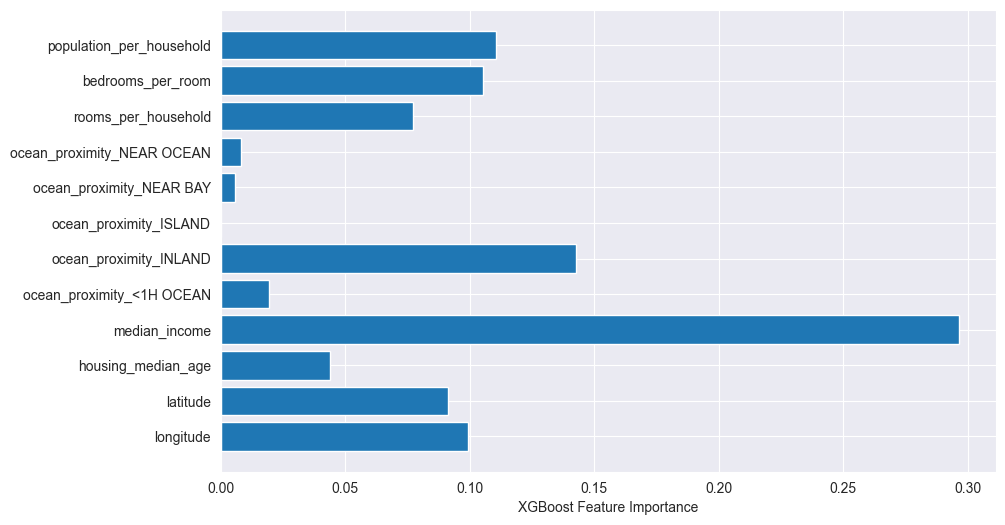

In [92]:
import matplotlib.pyplot as plt

# Plot top feature importances
plt.figure(figsize=(10, 6))
plt.barh(xtrain.columns, model.feature_importances_)
plt.xlabel("XGBoost Feature Importance")
plt.show()

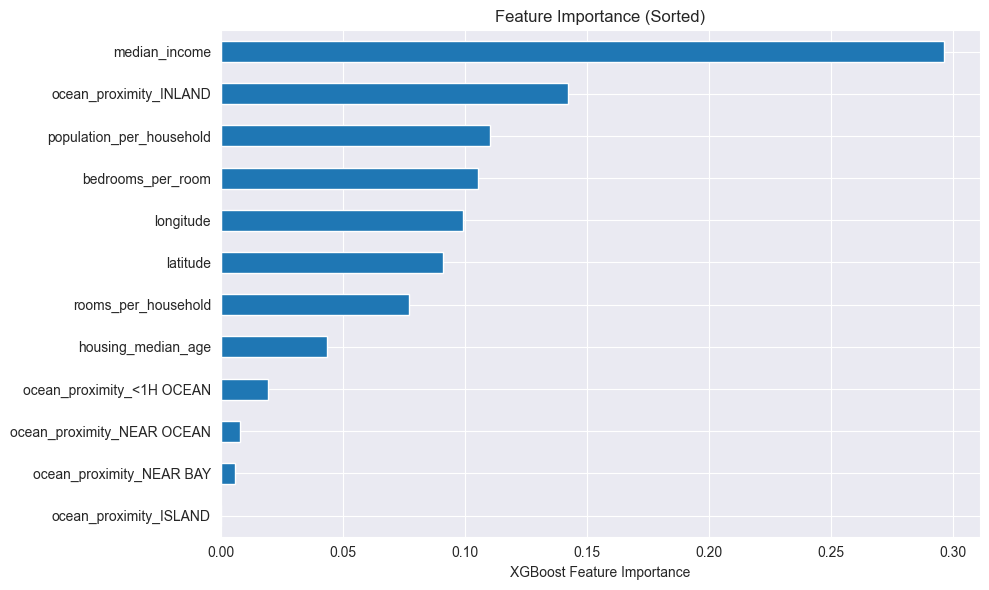

In [93]:
import matplotlib.pyplot as plt
import pandas as pd

# Create a Series of importances and sort them
importances = pd.Series(model.feature_importances_, index=xtrain.columns).sort_values()

# Plot sorted bars
plt.figure(figsize=(10, 6))
importances.plot(kind='barh')
plt.xlabel("XGBoost Feature Importance")
plt.title("Feature Importance (Sorted)")
plt.tight_layout()
plt.show()